## **Deep Learning based Antimicrobial Susceptibility Phenotyping Detection**

Dataset Link: https://ora.ox.ac.uk/objects/uuid:12153432-e8b3-4398-a395-abfb980bd84e

In [1]:
url = "https://ora.ox.ac.uk/objects/uuid:12153432-e8b3-4398-a395-abfb980bd84e/files/rjw827c35g"
filename = "oxford_data.zip"

# Use wget for downloading
!wget -O {filename} {url}

import os

if os.path.exists(filename):
    print(f"Dataset downloaded successfully as {filename}")
else:
    print(f"Failed to download dataset using wget. Please check the URL and try again.")

--2026-03-31 08:04:02--  https://ora.ox.ac.uk/objects/uuid:12153432-e8b3-4398-a395-abfb980bd84e/files/rjw827c35g
Resolving ora.ox.ac.uk (ora.ox.ac.uk)... 104.20.30.6, 172.66.159.143, 2606:4700:10::ac42:9f8f, ...
Connecting to ora.ox.ac.uk (ora.ox.ac.uk)|104.20.30.6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘oxford_data.zip’

oxford_data.zip         [         <=>        ]   4.83G  27.4MB/s    in 3m 4s   

2026-03-31 08:07:06 (27.0 MB/s) - ‘oxford_data.zip’ saved [5189672803]

Dataset downloaded successfully as oxford_data.zip


In [2]:
import os

# Unzip the downloaded file
!unzip -q oxford_data.zip

# # Verify extraction by listing contents
# if os.path.exists("Zagajewski_Data/Data"):
#     print("Dataset unzipped successfully. Contents:")
#     !ls -F Data
# else:
#     print("Failed to unzip the dataset or 'Data' directory not found.")

Dataset unzipped successfully. Contents:
ls: cannot access 'Data': No such file or directory


#### **Libraries**

In [3]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

warnings.filterwarnings('ignore')

#### **Count of Images from each folder**

In [4]:
raw_parent_dir = "Zagajewski_Data/Data/MG1655/All_images"
shutil.rmtree(os.path.join(raw_parent_dir, "COAMOX+ETOH"))
folder_names = ['WT+ETOH', 'CIP+ETOH', 'GENT+ETOH', 'RIF+ETOH']
for f in folder_names:
    old_name = os.path.join(raw_parent_dir, f)
    new_name = os.path.join(raw_parent_dir, f.split("+")[0])
    os.rename(old_name, new_name)
    count_of_images = len(os.listdir(os.path.join(raw_parent_dir, f.split("+")[0])))
    print(f"{new_name} has {count_of_images} images")

Zagajewski_Data/Data/MG1655/All_images/WT has 455 images
Zagajewski_Data/Data/MG1655/All_images/CIP has 285 images
Zagajewski_Data/Data/MG1655/All_images/GENT has 199 images
Zagajewski_Data/Data/MG1655/All_images/RIF has 279 images


#### **Complete Data about the tif file**

In [5]:
from PIL import Image
import tifffile

# Path to one image
main_path = os.path.join(raw_parent_dir, "WT/")
img_name = os.listdir(main_path)[0]
img_path = os.path.join(main_path, img_name)

print("Image Path:", img_path)
print("-"*50)

img_pil = Image.open(img_path)

img_array = np.array(img_pil)

print("\nNumPy Information")
print("Shape:", img_array.shape)
print("Data type:", img_array.dtype)

with tifffile.TiffFile(img_path) as tif:
    print("\nTIFF Metadata")
    print("Image shape:", tif.pages[0].shape)
    print("Image dtype:", tif.pages[0].dtype)

Image Path: Zagajewski_Data/Data/MG1655/All_images/WT/220913_1_MG1655_NA_AMR_combined_2_WT+ETOH_posXY5.tif
--------------------------------------------------

NumPy Information
Shape: (684, 420, 3)
Data type: uint8

TIFF Metadata
Image shape: (3, 684, 420)
Image dtype: uint16


#### **Sample image from Each Type**

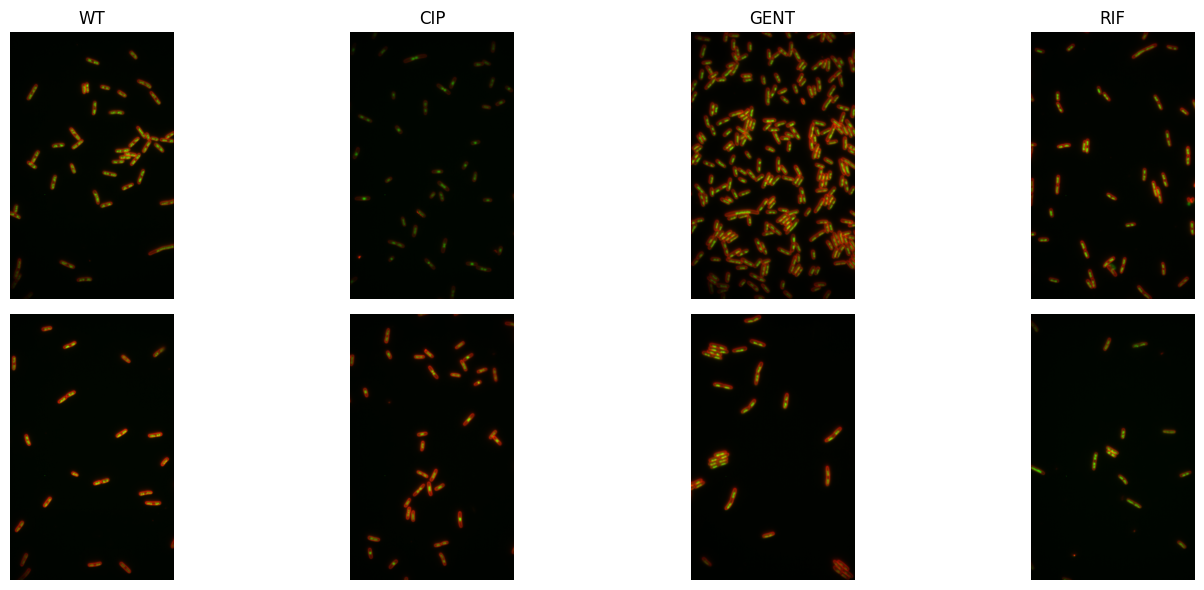

In [ ]:
import random

base_path = raw_parent_dir
classes = ["WT", "CIP", "GENT", "RIF"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 6))

for col, cls in enumerate(classes):

    class_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]

    selected = random.sample(images, 2)

    for row in range(2):

        img_path = os.path.join(class_path, selected[row])
        img = tifffile.imread(img_path)
        # (3, H, W) → (H, W, 3)
        img = np.transpose(img, (1, 2, 0))
        # Normalize safely
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        # Add class title only on top row
        if row == 0:
            axes[row, col].set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()

#### **Data Split**

In [7]:
# Paths
source_dir = raw_parent_dir
target_dir = "intermediate"

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]

    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


#### **Data After Train, Test and Validation split**

In [8]:
train_parent_dir = r"intermediate/train"
print("Count of Images for each class in train directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
WT has 318 images
CIP has 199 images
GENT has 139 images
RIF has 195 images


In [9]:
val_parent_dir = "intermediate/val"
print("Count of Images for each class in val directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
WT has 68 images
CIP has 42 images
GENT has 29 images
RIF has 41 images


In [10]:
test_parent_dir = "intermediate/test"
print("Count of Images for each class in test directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
WT has 69 images
CIP has 44 images
GENT has 31 images
RIF has 43 images


#### **Segmentation**

**Checking Nile Red Index**

intermediate/train/WT/220913_1_MG1655_NA_AMR_combined_2_WT+ETOH_posXY5.tif
Shape: (3, 684, 420)
Dtype: uint16


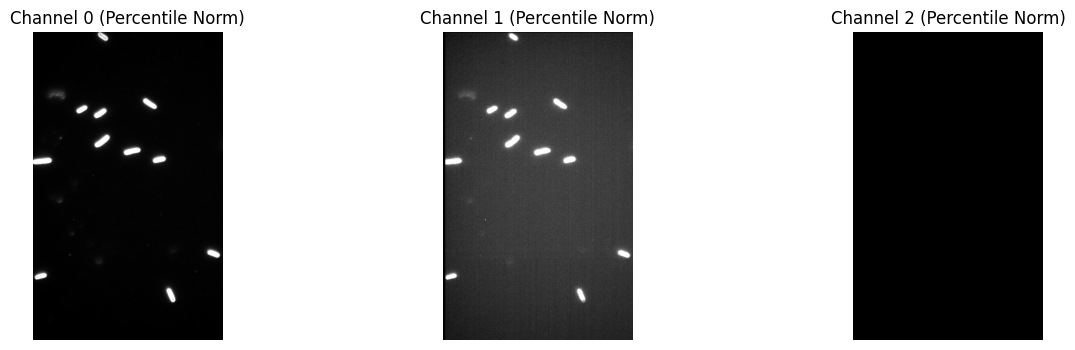

In [11]:
main_path = os.path.join(train_parent_dir, "WT/")
img_name = os.listdir(main_path)[0]
print(main_path+img_name)
img_path = os.path.join(main_path, img_name)

img = tifffile.imread(img_path)

print("Shape:", img.shape)
print("Dtype:", img.dtype)

plt.figure(figsize=(15,4))

for i in range(3):
    channel = img[i].astype(np.float32)

    p1, p99 = np.percentile(channel, (1, 99))
    channel = np.clip(channel, p1, p99)
    channel = (channel - p1) / (p99 - p1 + 1e-8)

    plt.subplot(1,3,i+1)
    plt.imshow(channel, cmap='gray')
    plt.title(f"Channel {i} (Percentile Norm)")
    plt.axis("off")

plt.show()

**Testing on Sample Image from train WT**

Number of detected cells: 9


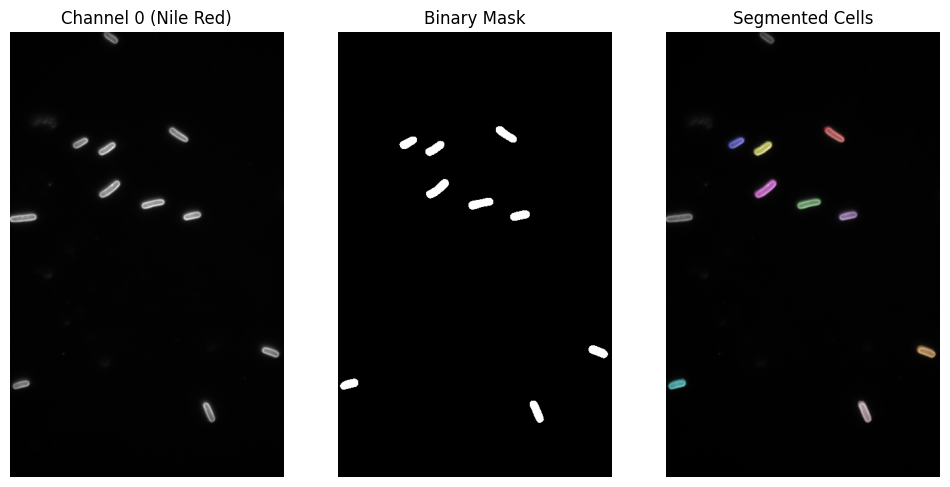

In [12]:
from skimage import filters, morphology, measure
from skimage.segmentation import clear_border
from skimage.color import label2rgb


img = tifffile.imread(img_path)

# From above plot we can clearly say that Channel 0 separates cells from background. So nile is at index 0
nile = img[0]

# Normalize to 0–255
nile_norm = cv2.normalize(nile, None, 0, 255, cv2.NORM_MINMAX)
nile_norm = nile_norm.astype(np.uint8)

from skimage.filters import threshold_local

block_size = 51   # must be odd
adaptive_thresh = threshold_local(nile_norm, block_size, offset=5)

binary = nile_norm > adaptive_thresh
binary = morphology.remove_small_objects(binary, min_size=100)
binary = clear_border(binary)

# Label
labels = measure.label(binary)
regions = measure.regionprops(labels)

print("Number of detected cells:", len(regions))

# Overlay
overlay = label2rgb(labels, image=nile_norm, bg_label=0)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(nile_norm, cmap='gray')
plt.title("Channel 0 (Nile Red)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Segmented Cells")
plt.axis("off")

plt.show()

**Segmenting Train, Val and Test Data**

In [13]:
from skimage import morphology, measure
from skimage.segmentation import clear_border, watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi

BASE_PATH = "intermediate"
DST_PATH = "segmented images"
SPLITS = ["train", "val", "test"]

NILE_CHANNEL = 0
MIN_CELL_AREA = 200
RESIZE_SIZE = 128

# Create CLAHE once (faster)
CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

In [14]:
def pad_to_square(img):
    h, w, c = img.shape
    size = max(h, w)
    padded = np.zeros((size, size, c), dtype=img.dtype)

    y_off = (size - h) // 2
    x_off = (size - w) // 2

    padded[y_off:y_off+h, x_off:x_off+w] = img
    return padded

In [ ]:
# Segmentation Function
def segment_cells(nile_img):
    nile = cv2.normalize(nile_img, None, 0, 255, cv2.NORM_MINMAX)
    nile = nile.astype(np.uint8)
    enhanced = CLAHE.apply(nile)
    blur = cv2.GaussianBlur(enhanced, (3,3), 0)
    adaptive = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        51, 5
    )
    binary = adaptive.astype(bool)
    binary = morphology.remove_small_objects(binary, min_size=100)
    binary = morphology.remove_small_holes(binary, area_threshold=100)
    binary = clear_border(binary)
    if np.sum(binary) == 0:
        return None
    distance = ndi.distance_transform_edt(binary)
    local_max = peak_local_max(
        distance,
        min_distance=10,
        labels=binary
    )
    markers = np.zeros_like(distance, dtype=np.int32)
    markers[tuple(local_max.T)] = np.arange(1, len(local_max)+1)
    labels = watershed(-distance, markers, mask=binary)
    return labels

In [16]:
for split in SPLITS:

    print(f"\nProcessing {split} set...")

    input_split = os.path.join(BASE_PATH, split)
    output_split = os.path.join(DST_PATH, f"{split}_segmented")

    for cls in classes:

        input_class = os.path.join(input_split, cls)
        output_class = os.path.join(output_split, cls)
        os.makedirs(output_class, exist_ok=True)

        images = [f for f in os.listdir(input_class) if f.endswith(".tif")]

        cell_id = 0

        for img_name in images:

            img_path = os.path.join(input_class, img_name)

            try:
                img = tifffile.imread(img_path)
            except:
                continue

            nile = img[NILE_CHANNEL]

            labels = segment_cells(nile)

            if labels is None:
                continue

            regions = measure.regionprops(labels)

            full_img = np.transpose(img, (1,2,0))

            for region in regions:

                if region.area < MIN_CELL_AREA:
                    continue

                if region.eccentricity < 0.6:
                    continue

                minr, minc, maxr, maxc = region.bbox

                crop = full_img[minr:maxr, minc:maxc]
                mask = (labels[minr:maxr, minc:maxc] == region.label)

                # Apply mask safely
                crop = crop.copy()
                crop[~mask] = 0

                # Pad + resize
                crop = pad_to_square(crop)
                crop = cv2.resize(crop, (RESIZE_SIZE, RESIZE_SIZE))

                save_name = f"{cls}_{img_name[:-4]}_cell_{cell_id}.png"
                save_path = os.path.join(output_class, save_name)

                cv2.imwrite(save_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))

                cell_id += 1

        print(f"{cls}: {cell_id} cells saved")


Processing train set...
WT: 11628 cells saved
CIP: 6770 cells saved
GENT: 6236 cells saved
RIF: 8708 cells saved

Processing val set...
WT: 2624 cells saved
CIP: 1439 cells saved
GENT: 1582 cells saved
RIF: 1896 cells saved

Processing test set...
WT: 2764 cells saved
CIP: 1538 cells saved
GENT: 960 cells saved
RIF: 1752 cells saved


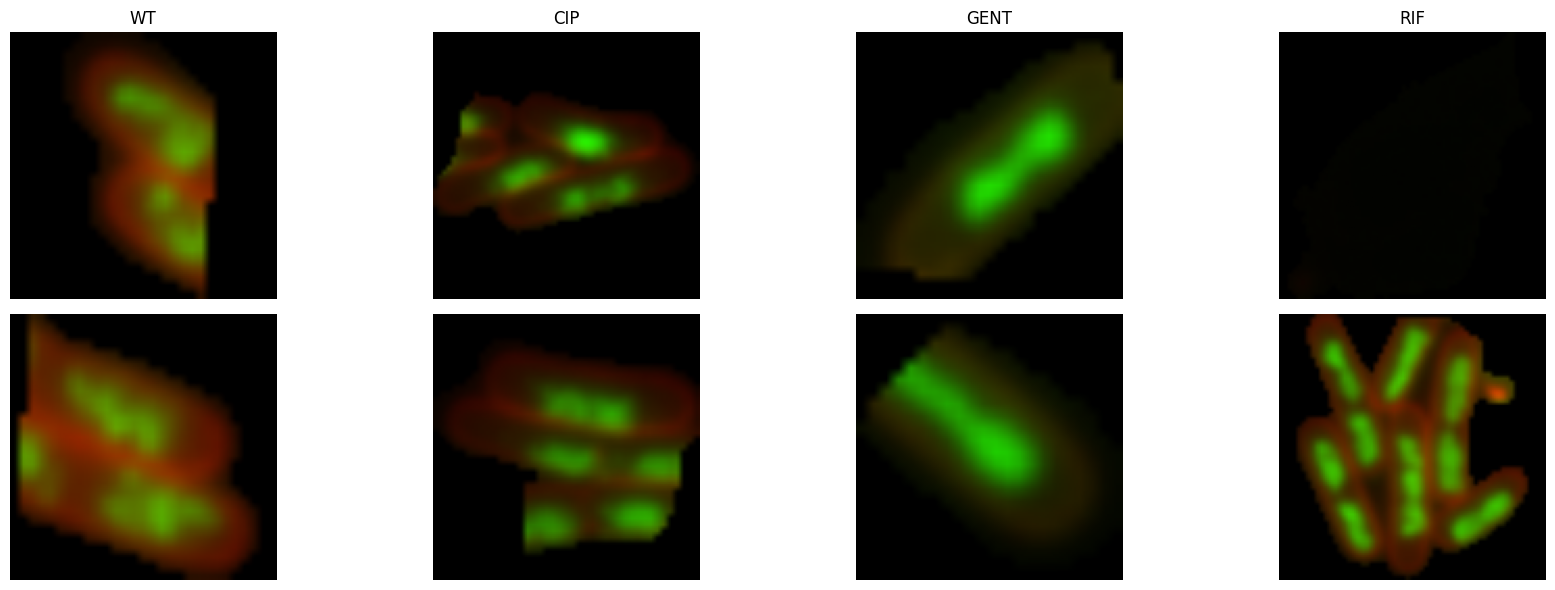

In [17]:
import matplotlib.image as mpimg

data_dir = 'segmented images/train_segmented'

fig, axes = plt.subplots(2, 4, figsize=(18, 6))

for col, cls in enumerate(classes):

    cls_path = os.path.join(data_dir, cls)

    # Get sorted images
    images = sorted([f for f in os.listdir(cls_path) if f.endswith(".png")])

    # Take first 2 images
    first_two = images[1:3]

    for row in range(2):

        img_path = os.path.join(cls_path, first_two[row])
        img = mpimg.imread(img_path)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        # Add class title only on top row
        if row == 0:
            axes[row, col].set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()

## **Class Imbalance Check**

In [18]:
data_dir = "segmented images/train_segmented"

class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Class Distribution:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

Class Distribution:
CIP: 6770
GENT: 6236
WT: 11628
RIF: 8708


In [19]:
counts = np.array(list(class_counts.values()))
imbalance_ratio = counts.max() / counts.min()

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")


Imbalance Ratio: 1.86


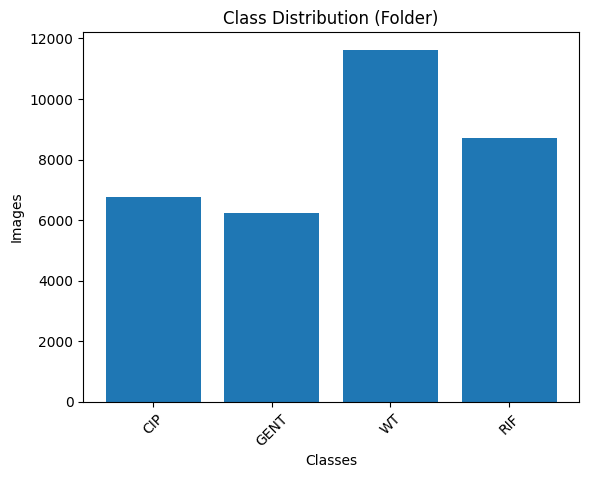

In [20]:
classes = list(class_counts.keys())
values = list(class_counts.values())

plt.figure()
plt.bar(classes, values)
plt.xticks(rotation=45)
plt.title("Class Distribution (Folder)")
plt.xlabel("Classes")
plt.ylabel("Images")
plt.show()

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (128, 128)
batch_size = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'segmented images/train_segmented',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    'segmented images/val_segmented',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 33342 images belonging to 4 classes.
Found 7541 images belonging to 4 classes.


In [22]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(1.2312407680945348), 1: np.float64(1.3366741500962156), 2: np.float64(0.9572232429949472), 3: np.float64(0.7168472652218782)}


## **Models**

In [23]:
all_model_metrics = []
class_len = train_generator.num_classes
epochs = 20

#### **CNN Model**

In [24]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import F1Score

**Model Building**

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [ ]:
cnn_model = Sequential([
    Input(shape=(128,128,3)),
    # First block
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    # Second block
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    # Third block
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    # Fourth block
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),
    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(class_len, activation='softmax')
])

In [27]:
# Compile with different optimizer settings
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [28]:
cnn_history = cnn_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 249s 424ms/step - accuracy: 0.3474 - f1_score: 0.3461 - loss: 1.6734 - precision: 0.3681 - recall: 0.2551 - val_accuracy: 0.1931 - val_f1_score: 0.0848 - val_loss: 2.0139 - val_precision: 0.1945 - val_recall: 0.1907
Epoch 2/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 191s 367ms/step - accuracy: 0.4177 - f1_score: 0.4170 - loss: 1.3880 - precision: 0.4506 - recall: 0.2999 - val_accuracy: 0.3952 - val_f1_score: 0.3201 - val_loss: 1.4547 - val_precision: 0.4434 - val_recall: 0.2249
Epoch 3/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 190s 364ms/step - accuracy: 0.4522 - f1_score: 0.4527 - loss: 1.2625 - precision: 0.4969 - recall: 0.3268 - val_accuracy: 0.3693 - val_f1_score: 0.2267 - val_loss: 1.5927 - val_precision: 0.3878 - val_recall: 0.3127
Epoch 4/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 192s 368ms/step - accuracy: 0.4810 - f1_score: 0.4810 - loss: 1.1900 - precision: 0.5289 - recall: 0.3480 - val_accuracy: 0.3664 - val_f1_score: 0.2274 - val_loss: 1.6826 - val_precision: 0.38

#### **DenseNet-169**

In [29]:
# Load the DenseNet169 model, pre-trained on ImageNet, without the top classification layer
b_model = DenseNet169(
    include_top=False,
    weights='imagenet',
    input_shape=(image_size[0], image_size[1], 3)
)

# Freeze the pre-trained layers
for layer in b_model.layers:
    layer.trainable = False

# Add custom classification layers
x = Flatten()(b_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(class_len, activation='softmax')(x)

densenet_model = Model(inputs=b_model.input, outputs=predictions)

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
# Compile the model
densenet_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

densenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 26,407,236 (100.74 MB)

 Trainable params: 13,764,356 (52.51 MB)

 Non-trainable params: 12,642,880 (48.23 MB)

In [31]:
densenet_history = densenet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 306s 508ms/step - accuracy: 0.5108 - f1_score: 0.5013 - loss: 1.1480 - precision: 0.6191 - recall: 0.3203 - val_accuracy: 0.6571 - val_f1_score: 0.6438 - val_loss: 0.8543 - val_precision: 0.7954 - val_recall: 0.4631
Epoch 2/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 205s 394ms/step - accuracy: 0.5967 - f1_score: 0.5861 - loss: 0.9883 - precision: 0.7000 - recall: 0.4382 - val_accuracy: 0.6737 - val_f1_score: 0.6641 - val_loss: 0.8128 - val_precision: 0.7776 - val_recall: 0.5323
Epoch 3/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 203s 390ms/step - accuracy: 0.6270 - f1_score: 0.6172 - loss: 0.9270 - precision: 0.7221 - recall: 0.4895 - val_accuracy: 0.6906 - val_f1_score: 0.6812 - val_loss: 0.7794 - val_precision: 0.7878 - val_recall: 0.5631
Epoch 4/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 199s 382ms/step - accuracy: 0.6387 - f1_score: 0.6285 - loss: 0.9063 - precision: 0.7304 - recall: 0.5088 - val_accuracy: 0.7010 - val_f1_score: 0.6924 - val_loss: 0.7559 - val_precision: 0.79

#### **Vision Transformers**

In [ ]:
from tensorflow.keras import layers, models, optimizers

In [32]:
# ViT parameters
num_patches = (image_size[0] // 16) ** 2
projection_dim = 64
num_heads = 8
transformer_layers = 8
mlp_head_units = [2048, 1024]

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

In [ ]:
def create_vit_classifier():
    inputs = layers.Input(shape=(image_size[0], image_size[1], 3))
    # Create patches
    patches = Patches(patch_size=16)(inputs)
    # Encode patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)
    # Create multiple Transformer blocks
    for _ in range(transformer_layers):
        # Layer normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Multi-head self-attention
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = models.Sequential([
            layers.Dense(projection_dim * 2, activation="gelu"),
            layers.Dropout(0.1),
            layers.Dense(projection_dim, activation="gelu"),
            layers.Dropout(0.1)
        ])(x3)
        # Skip connection 2
        encoded_patches = layers.Add()([x3, x2])
    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP head.
    for units in mlp_head_units:
        representation = layers.Dense(units, activation="gelu")(representation)
        representation = layers.Dropout(0.5)(representation)

    logits = layers.Dense(class_len, activation="softmax")(representation)
    # Create the Keras model.
    model = models.Model(inputs=inputs, outputs=logits)
    return model

vit_model = create_vit_classifier()

In [34]:
# Compile the model
vit_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

vit_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │     53,312 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ sequential_1[0][… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 64, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 64)    │          0 │ sequential_2[0][… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat

 Total params: 11,742,404 (44.79 MB)

 Trainable params: 11,742,404 (44.79 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
vit_history = vit_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 270s 423ms/step - accuracy: 0.3209 - f1_score: 0.3186 - loss: 1.5119 - precision: 0.3428 - recall: 0.1430 - val_accuracy: 0.3769 - val_f1_score: 0.3397 - val_loss: 1.2807 - val_precision: 0.5902 - val_recall: 0.0095
Epoch 2/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 188s 360ms/step - accuracy: 0.3590 - f1_score: 0.3588 - loss: 1.2918 - precision: 0.4309 - recall: 0.1091 - val_accuracy: 0.3659 - val_f1_score: 0.3519 - val_loss: 1.3023 - val_precision: 0.4719 - val_recall: 0.1001
Epoch 3/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 187s 359ms/step - accuracy: 0.3744 - f1_score: 0.3727 - loss: 1.2596 - precision: 0.4627 - recall: 0.1175 - val_accuracy: 0.3790 - val_f1_score: 0.3680 - val_loss: 1.2565 - val_precision: 0.4895 - val_recall: 0.0618
Epoch 4/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 186s 357ms/step - accuracy: 0.4301 - f1_score: 0.4294 - loss: 1.1967 - precision: 0.5076 - recall: 0.1896 - val_accuracy: 0.4474 - val_f1_score: 0.4281 - val_loss: 1.1731 - val_precision: 0.50

## **Accuracy & Loss Plots**

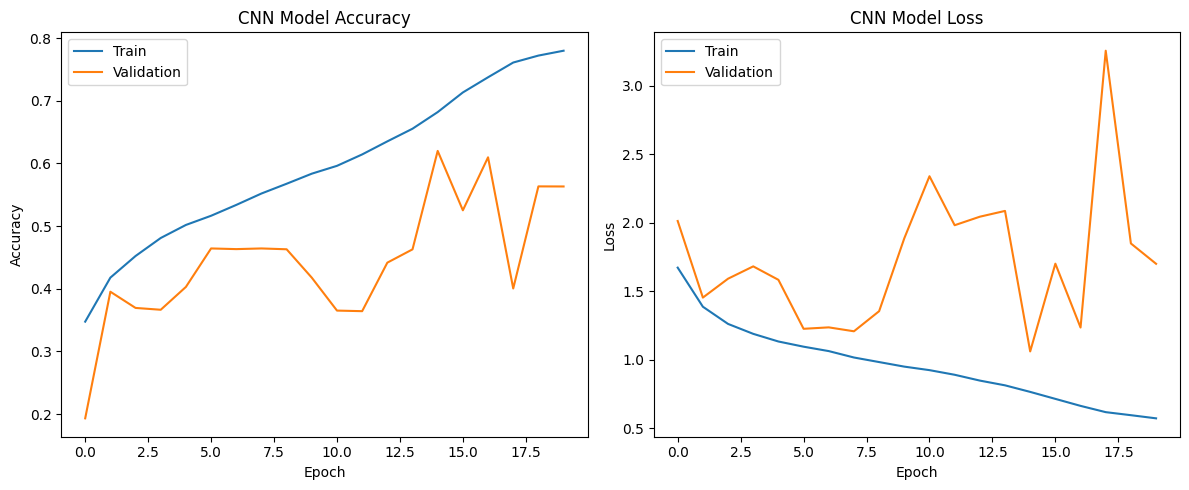

In [36]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

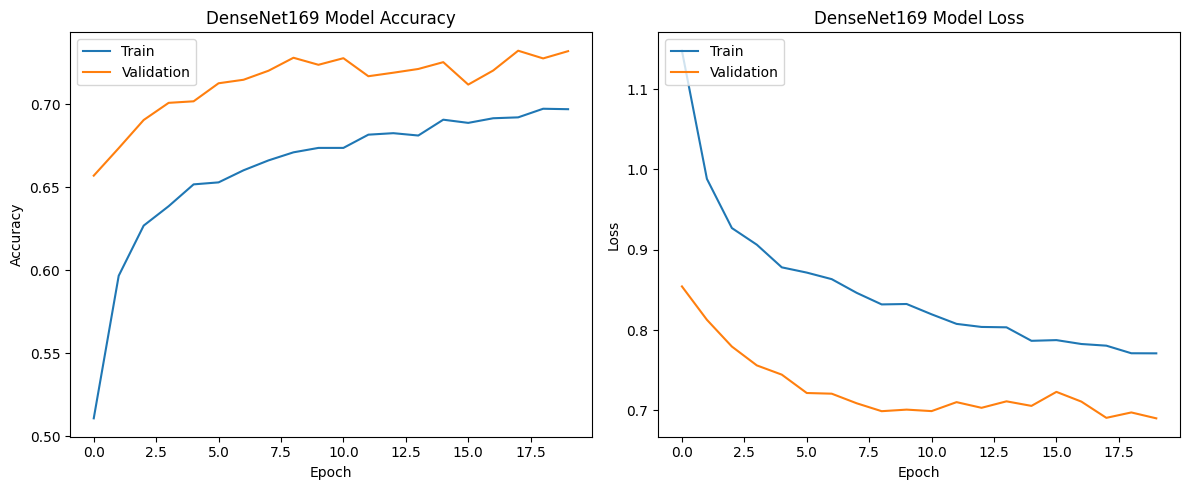

In [37]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(densenet_history.history['accuracy'])
plt.plot(densenet_history.history['val_accuracy'])
plt.title('DenseNet169 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(densenet_history.history['loss'])
plt.plot(densenet_history.history['val_loss'])
plt.title('DenseNet169 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

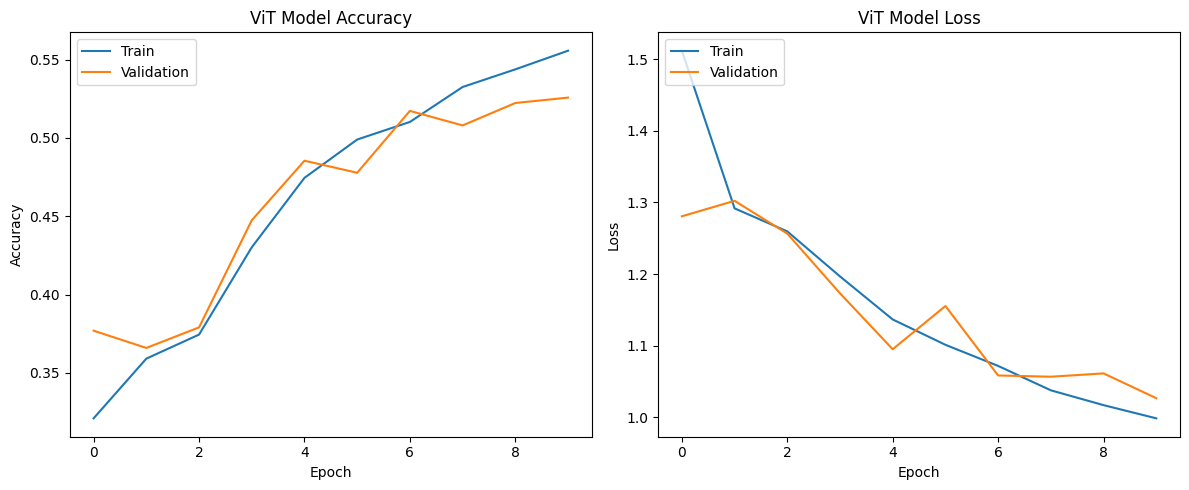

In [38]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(vit_history.history['accuracy'])
plt.plot(vit_history.history['val_accuracy'])
plt.title('ViT Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(vit_history.history['loss'])
plt.plot(vit_history.history['val_loss'])
plt.title('ViT Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## **Evaluation Metrics**

In [39]:
def evaluate_model(model, name, generator):
    print(f"\nEvaluating {name}...")
    results = model.evaluate(generator, verbose=0)
    metrics = {
        'Model': name,
        'Loss': results[0],
        'Accuracy': results[1],
        'Precision': results[2],
        'Recall': results[3],
        'F1-Score': results[4]
    }
    return metrics

In [40]:
# Evaluate CNN Model
cnn_metrics = evaluate_model(cnn_model, 'CNN', val_generator)
all_model_metrics.append(cnn_metrics)


Evaluating CNN...


In [41]:
# Evaluate DenseNet169 Model
densenet_metrics = evaluate_model(densenet_model, 'DenseNet169', val_generator)
all_model_metrics.append(densenet_metrics)


Evaluating DenseNet169...


In [42]:
# Evaluate ViT Model
vit_metrics = evaluate_model(vit_model, 'Vision Transformer', val_generator)
all_model_metrics.append(vit_metrics)


Evaluating Vision Transformer...


In [43]:
# Create DataFrame
metrics_df = pd.DataFrame(all_model_metrics)
print("\nAll Model Evaluation Metrics:")
print(metrics_df)


All Model Evaluation Metrics:
                Model      Loss  Accuracy  Precision    Recall  F1-Score
0                 CNN  1.061671  0.619944   0.645460  0.573134  0.605077
1         DenseNet169  0.689991  0.732131   0.813978  0.616231  0.722073
2  Vision Transformer  1.280691  0.376873   0.590164  0.009548  0.339720


## **Visualization of Evaluation Metrics**

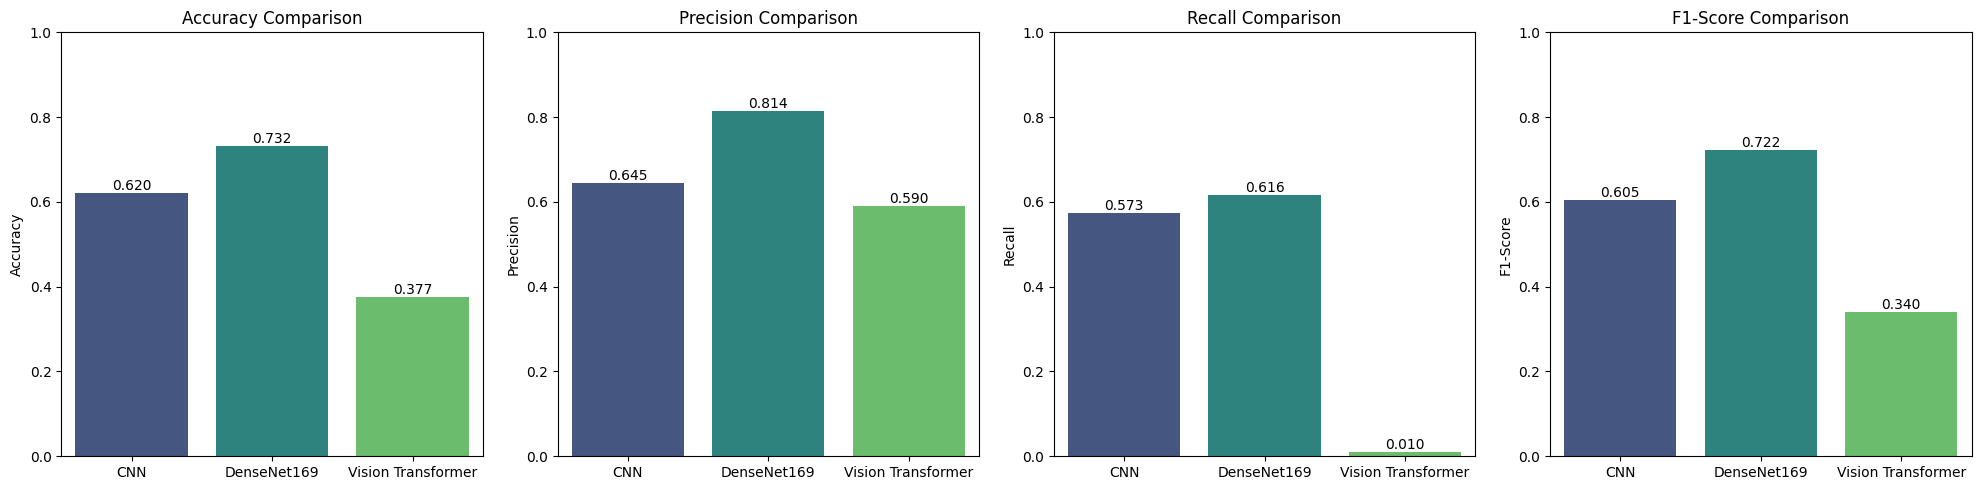

In [44]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 1) # Metrics like accuracy, precision, recall, f1-score are usually between 0 and 1
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f') # Show values on top of bars

plt.tight_layout()
plt.show()

## **ROC-AUC Plot**

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix, classification_report

Calculating ROC-AUC for CNN...
Calculating ROC-AUC for DenseNet169...
Calculating ROC-AUC for Vision Transformer...


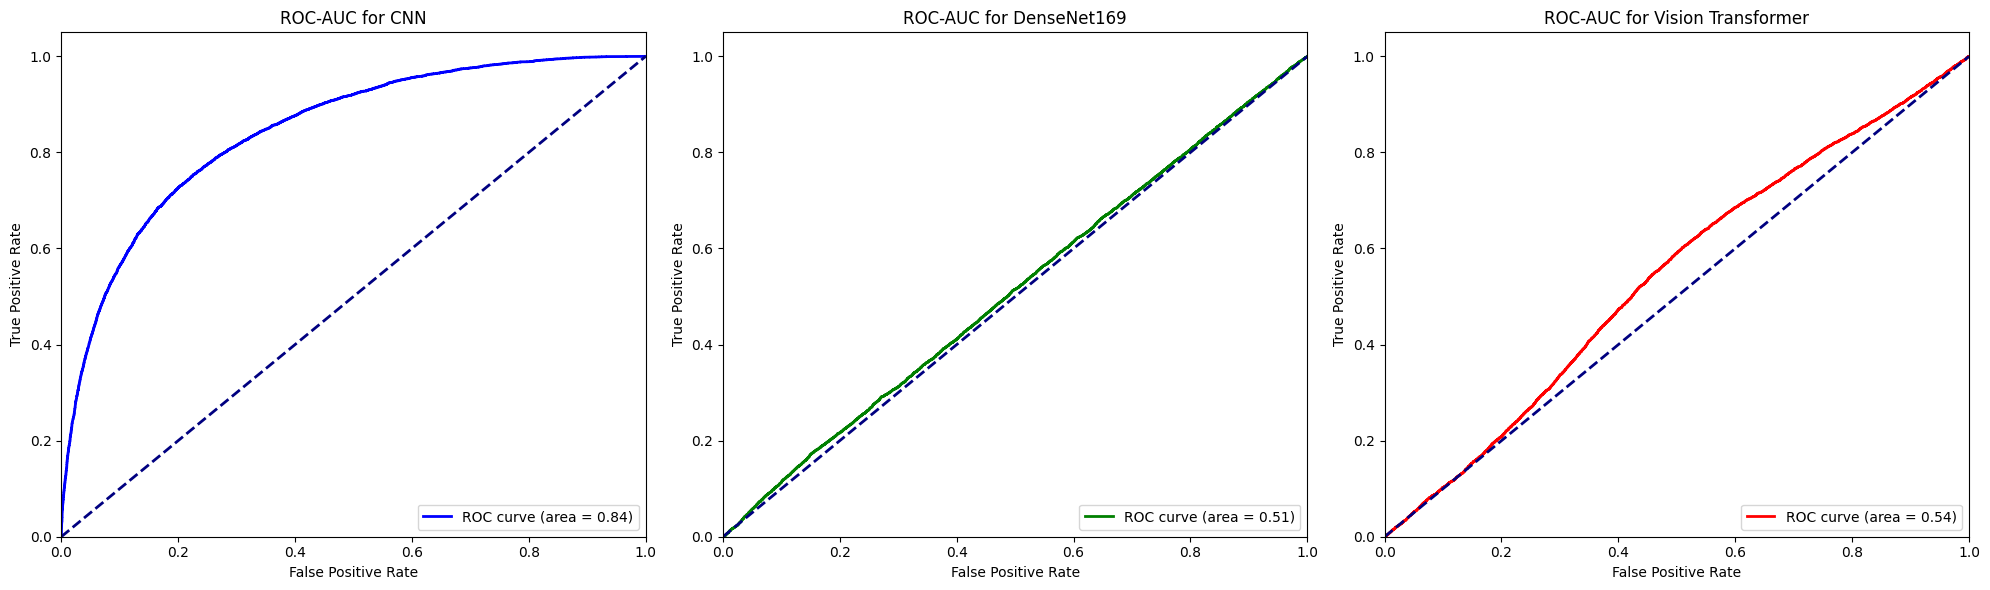

In [45]:
val_generator.reset()
true_labels_indices = val_generator.classes[val_generator.index_array]

label_binarizer = LabelBinarizer()
label_binarizer.fit(true_labels_indices)
true_labels_one_hot = label_binarizer.transform(true_labels_indices)

models_for_roc = {
    'CNN': cnn_model,
    'DenseNet169': densenet_model,
    'Vision Transformer': vit_model
}

fig, axes = plt.subplots(1, len(models_for_roc), figsize=(20, 6))
colors = ['blue', 'green', 'red']

for i, (model_name, model) in enumerate(models_for_roc.items()):
    print(f"Calculating ROC-AUC for {model_name}...")
    val_generator.reset()

    # Get predicted probabilities
    predictions = model.predict(val_generator, verbose=0)

    # Calculate micro-average ROC curve and AUC
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(true_labels_one_hot.ravel(), predictions.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot the ROC curve
    axes[i].plot(fpr["micro"], tpr["micro"], color=colors[i], lw=2,
             label=f'ROC curve (area = {roc_auc["micro"]:.2f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC-AUC for {model_name}')
    axes[i].legend(loc="lower right")

plt.tight_layout()
plt.show()

## **Confusion Matrix**

Generating confusion matrix for CNN...
Generating confusion matrix for DenseNet169...
Generating confusion matrix for Vision Transformer...


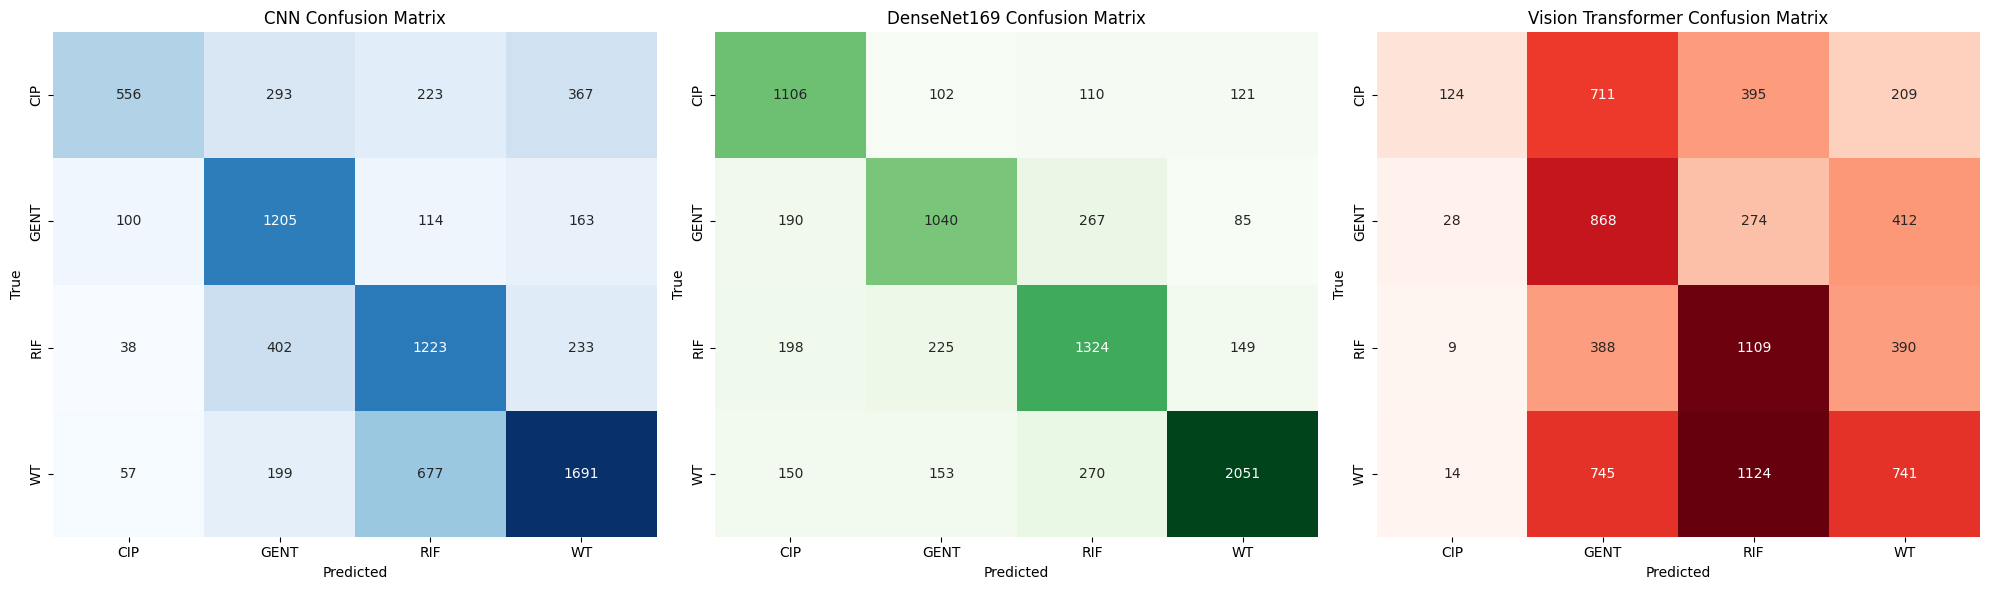

In [46]:
class_names = list(train_generator.class_indices.keys())

models_to_evaluate = {
    'CNN': cnn_model,
    'DenseNet169': densenet_model,
    'Vision Transformer': vit_model
}

# Create a figure for confusion matrices
fig, axes = plt.subplots(1, len(models_to_evaluate), figsize=(20, 6))
# Assign different color maps for visual distinction
cmaps = ['Blues', 'Greens', 'Reds']
colors_idx = 0

for i, (model_name, model) in enumerate(models_to_evaluate.items()):
    print(f"Generating confusion matrix for {model_name}...")
    val_generator.reset()

    true_labels = val_generator.classes[val_generator.index_array]

    predictions = model.predict(val_generator, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    # Calculate confusion matrix
    cm = confusion_matrix(true_labels, predicted_classes)

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[colors_idx], cbar=False, ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    colors_idx = (colors_idx + 1) % len(cmaps)

plt.tight_layout()
plt.show()

In [47]:
print("\n--- Classification Reports ---")
for model_name, model in models_to_evaluate.items():
    val_generator.reset()
    true_labels = val_generator.classes[val_generator.index_array]
    predictions = model.predict(val_generator, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(true_labels, predicted_classes, target_names=class_names, zero_division=0))


--- Classification Reports ---

Classification Report for CNN:
              precision    recall  f1-score   support

         CIP       0.74      0.39      0.51      1439
        GENT       0.57      0.76      0.65      1582
         RIF       0.55      0.65      0.59      1896
          WT       0.69      0.64      0.67      2624

    accuracy                           0.62      7541
   macro avg       0.64      0.61      0.61      7541
weighted avg       0.64      0.62      0.61      7541


Classification Report for DenseNet169:
              precision    recall  f1-score   support

         CIP       0.67      0.77      0.72      1439
        GENT       0.68      0.66      0.67      1582
         RIF       0.67      0.70      0.68      1896
          WT       0.85      0.78      0.82      2624

    accuracy                           0.73      7541
   macro avg       0.72      0.73      0.72      7541
weighted avg       0.74      0.73      0.73      7541


Classification Report for

## **Test Predictions**

In [48]:
if 'metrics_df' not in locals() or metrics_df.empty:
    print("Metrics DataFrame is not available or empty. Please run evaluation cells first.")
    best_model_name = 'DenseNet169'
    best_model = densenet_model
else:
    best_model_row = metrics_df.loc[metrics_df['F1-Score'].idxmax()]
    best_model_name = best_model_row['Model']

    if best_model_name == 'CNN':
        best_model = cnn_model
    elif best_model_name == 'DenseNet169':
        best_model = densenet_model
    elif best_model_name == 'Vision Transformer':
        best_model = vit_model
    else:
        raise ValueError("Best model not found among available models.")

print(f"Best Model identified: {best_model_name} (based on F1-Score)")

Best Model identified: DenseNet169 (based on F1-Score)


In [49]:
test_segmented_dir = 'segmented images/test_segmented'
all_test_image_data = []

class_indices = train_generator.class_indices
ordered_class_names = [None] * len(class_indices)
for name, index in class_indices.items():
    ordered_class_names[index] = name

for class_label in os.listdir(test_segmented_dir):
    class_path = os.path.join(test_segmented_dir, class_label)
    if os.path.isdir(class_path):
        for img_filename in os.listdir(class_path):
            if img_filename.lower().endswith('.png'):
                img_path = os.path.join(class_path, img_filename)
                all_test_image_data.append((img_path, class_label))

print(f"Total test images found in '{test_segmented_dir}': {len(all_test_image_data)}")

Total test images found in 'segmented images/test_segmented': 7014


Selected 4 images for prediction and display.


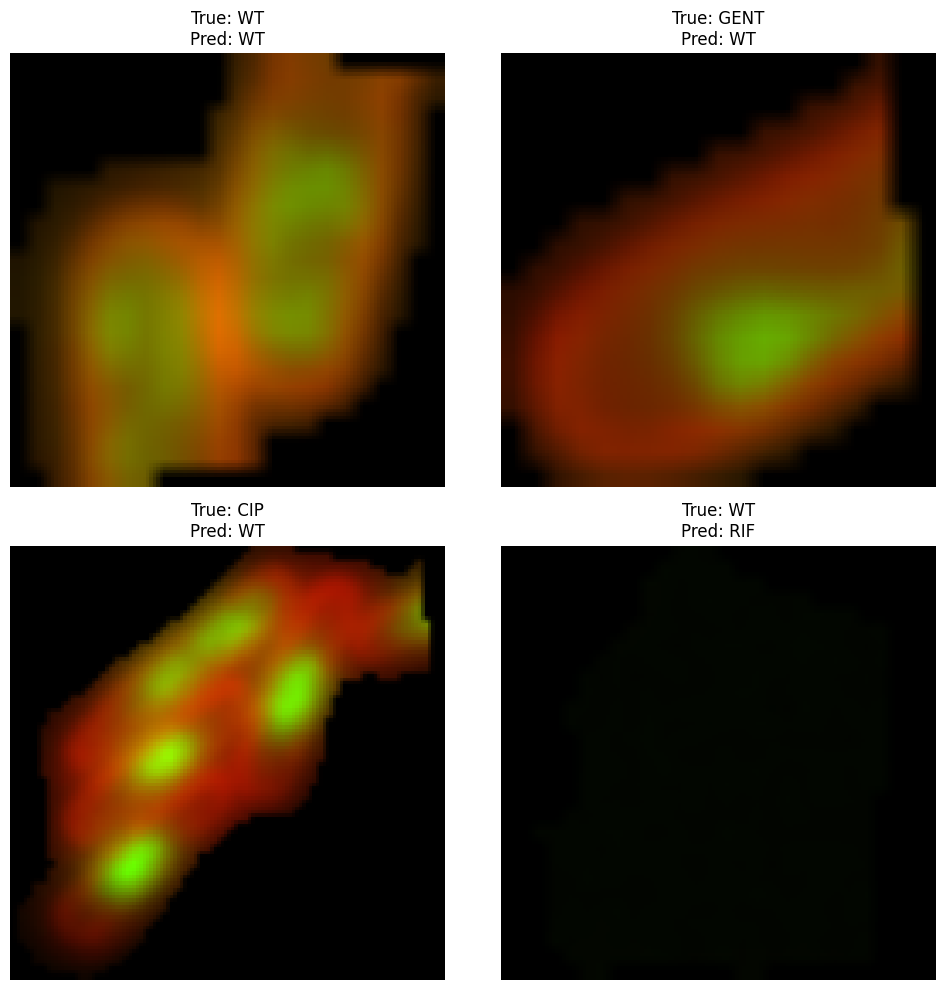

In [50]:
num_images_to_sample = min(4, len(all_test_image_data))
if num_images_to_sample == 0:
    print("No test images found to display. Exiting.")
else:
    selected_images = random.sample(all_test_image_data, num_images_to_sample)

    print(f"Selected {len(selected_images)} images for prediction and display.")

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for i, (img_path, true_label) in enumerate(selected_images):
        if i >= len(axes):
            break

        # Load image
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Preprocess for model
        img_resized = cv2.resize(img_rgb, image_size)
        img_normalized = img_resized / 255.0
        img_batch = np.expand_dims(img_normalized, axis=0)

        # Predict
        prediction_probs = best_model.predict(img_batch, verbose=0)
        predicted_class_idx = np.argmax(prediction_probs, axis=1)[0]
        predicted_label = ordered_class_names[predicted_class_idx]

        # Display
        axes[i].imshow(img_rgb)
        axes[i].set_title(f'True: {true_label}\nPred: {predicted_label}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()